# PyTorch GPU Demo

This notebook walks through:
1. **GPU detection** — confirm CUDA is wired through the container.
2. **CPU vs GPU matmul benchmark** — including warm-up and scaling across sizes.
3. **Toy training** — a 2-layer MLP on the two-moons dataset.
4. **CPU vs GPU training time** for a slightly larger MLP.
5. **Decision boundary** plot.
6. **Extending with PyTorch Lightning** at runtime.

In [1]:
import torch
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"CUDA ver : {torch.version.cuda}")
    print(f"cuDNN    : {torch.backends.cudnn.version()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_cpu = torch.device("cpu")

PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : NVIDIA RTXA6000-24Q
VRAM     : 25.5 GB
CUDA ver : 12.8
cuDNN    : 91002


## 1. CPU vs GPU matrix multiply — single size

We compare a 4096×4096 dense matmul on CPU and GPU.

In [2]:
import time

def bench_matmul(device, N, repeats=5, warmup=2):
    a = torch.randn(N, N, device=device)
    b = torch.randn(N, N, device=device)

    # warm-up (untimed)
    for _ in range(warmup):
        c = a @ b
        if device.type == "cuda":
            torch.cuda.synchronize()

    # timed runs
    times = []
    for _ in range(repeats):
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        c = a @ b
        if device.type == "cuda":
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
    return min(times)  # use best of N — the rest are usually slowed by jitter

N = 4096
t_cpu = bench_matmul(device_cpu, N)
print(f"CPU matmul {N}x{N}: {t_cpu*1000:8.1f} ms")

if torch.cuda.is_available():
    t_gpu = bench_matmul(device, N)
    print(f"GPU matmul {N}x{N}: {t_gpu*1000:8.1f} ms   (speedup: {t_cpu/t_gpu:5.1f}x)")

CPU matmul 4096x4096:    406.2 ms
GPU matmul 4096x4096:      9.9 ms   (speedup:  41.0x)


## 2. Scaling benchmark — how the gap widens with size


N=  256  CPU=     0.1 ms  GPU=    0.04 ms
N=  512  CPU=     0.8 ms  GPU=    0.05 ms
N= 1024  CPU=     6.3 ms  GPU=    0.14 ms
N= 2048  CPU=    55.3 ms  GPU=    0.75 ms


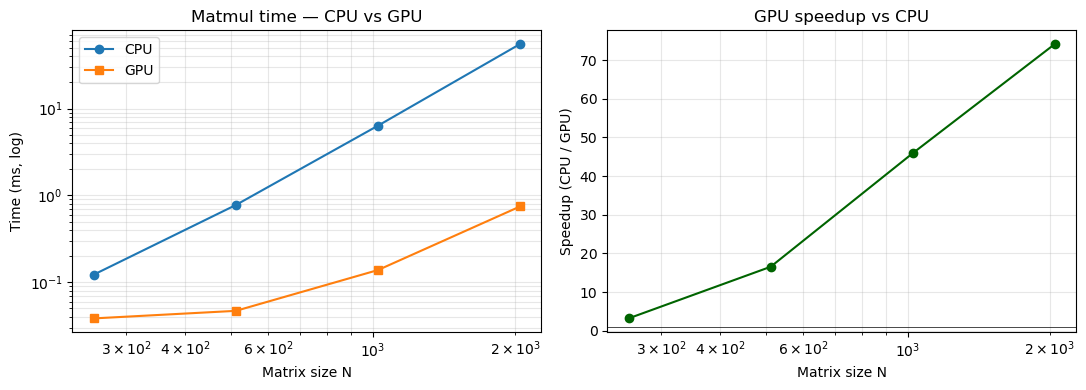

In [3]:
import matplotlib.pyplot as plt
import numpy as np

sizes = [256, 512, 1024, 2048]
cpu_times, gpu_times = [], []
for N in sizes:
    cpu_times.append(bench_matmul(device_cpu, N) * 1000)
    gpu_times.append(bench_matmul(device, N) * 1000 if torch.cuda.is_available() else float("nan"))
    print(f"N={N:5d}  CPU={cpu_times[-1]:8.1f} ms  GPU={gpu_times[-1]:8.2f} ms")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].loglog(sizes, cpu_times, "o-", label="CPU")
axes[0].loglog(sizes, gpu_times, "s-", label="GPU")
axes[0].set_xlabel("Matrix size N"); axes[0].set_ylabel("Time (ms, log)")
axes[0].set_title("Matmul time — CPU vs GPU"); axes[0].legend(); axes[0].grid(True, which="both", alpha=0.3)

speedups = [c/g for c, g in zip(cpu_times, gpu_times)]
axes[1].semilogx(sizes, speedups, "o-", color="darkgreen")
axes[1].axhline(1, color="black", lw=0.5)
axes[1].set_xlabel("Matrix size N"); axes[1].set_ylabel("Speedup (CPU / GPU)")
axes[1].set_title("GPU speedup vs CPU"); axes[1].grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Toy classification: 2-layer MLP on two-moons

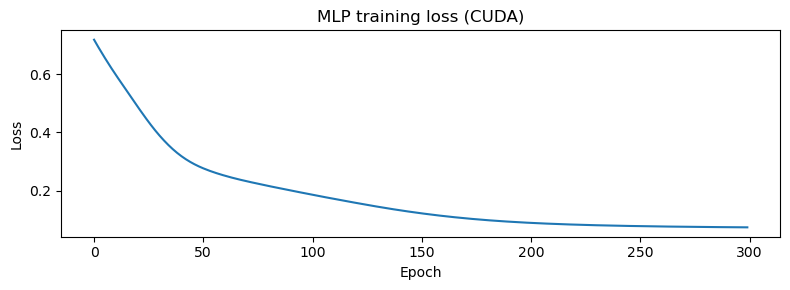

Final loss: 0.0737


In [4]:
import torch.nn as nn
from sklearn.datasets import make_moons

X_np, y_np = make_moons(n_samples=2000, noise=0.2, random_state=42)
X = torch.tensor(X_np, dtype=torch.float32, device=device)
y = torch.tensor(y_np, dtype=torch.long, device=device)

model = nn.Sequential(
    nn.Linear(2, 64), nn.ReLU(),
    nn.Linear(64, 64), nn.ReLU(),
    nn.Linear(64, 2),
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

losses = []
for epoch in range(300):
    optimizer.zero_grad()
    loss = criterion(model(X), y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"MLP training loss ({device.type.upper()})")
plt.tight_layout(); plt.show()
print(f"Final loss: {losses[-1]:.4f}")

## 4. CPU vs GPU training time — bigger MLP

In [5]:
from sklearn.datasets import make_classification

X_np, y_np = make_classification(
    n_samples=200_000, n_features=128, n_informative=40,
    n_classes=4, random_state=42,
)
X_np = X_np.astype("float32")
y_np = y_np.astype("int64")

def train_mlp(dev, epochs=20, batch_size=4096):
    Xt = torch.from_numpy(X_np).to(dev)
    yt = torch.from_numpy(y_np).to(dev)
    net = nn.Sequential(
        nn.Linear(128, 512), nn.ReLU(),
        nn.Linear(512, 512), nn.ReLU(),
        nn.Linear(512, 4),
    ).to(dev)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()

    # warm-up
    out = net(Xt[:batch_size]); crit(out, yt[:batch_size]).backward()
    if dev.type == "cuda":
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    for _ in range(epochs):
        perm = torch.randperm(Xt.shape[0], device=dev)
        for i in range(0, Xt.shape[0], batch_size):
            idx = perm[i:i+batch_size]
            opt.zero_grad()
            loss = crit(net(Xt[idx]), yt[idx])
            loss.backward()
            opt.step()
    if dev.type == "cuda":
        torch.cuda.synchronize()
    return time.perf_counter() - t0

t_cpu = train_mlp(device_cpu)
print(f"CPU training : {t_cpu:6.2f} s")
if torch.cuda.is_available():
    t_gpu = train_mlp(device)
    print(f"GPU training : {t_gpu:6.2f} s   (speedup: {t_cpu/t_gpu:.1f}x)")

CPU training :  34.44 s
GPU training :   1.79 s   (speedup: 19.3x)


## 5. Decision boundary (small MLP from step 3)

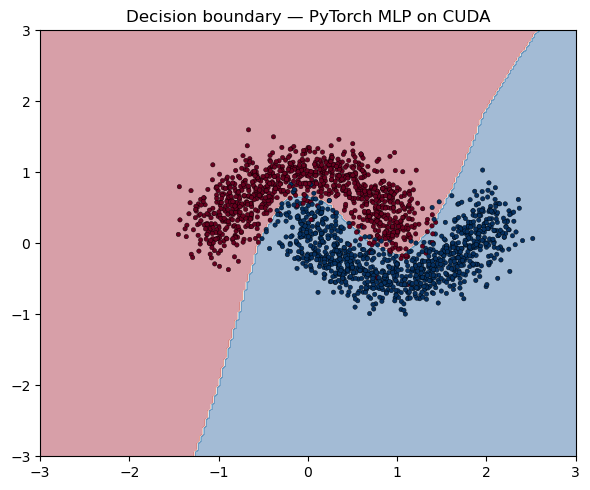

In [6]:
X_np_moons, y_np_moons = make_moons(n_samples=2000, noise=0.2, random_state=42)
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32, device=device)
with torch.no_grad():
    preds = model(grid).argmax(1).cpu().numpy().reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, preds, alpha=0.4, cmap="RdBu")
plt.scatter(X_np_moons[:, 0], X_np_moons[:, 1], c=y_np_moons,
            cmap="RdBu", s=10, edgecolors="k", linewidths=0.3)
plt.title(f"Decision boundary — PyTorch MLP on {device.type.upper()}")
plt.tight_layout(); plt.show()

## 6. Extending with PyTorch Lightning

In [7]:
import lightning as L
from torch.utils.data import TensorDataset, DataLoader

class LitMLP(L.LightningModule):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 64), nn.ReLU(), nn.Linear(64, 2))

    def forward(self, x):
        return self.net(x)

    def training_step(self, batch, _):
        x, y = batch
        loss = nn.functional.cross_entropy(self(x), y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

X_moons = torch.tensor(X_np_moons, dtype=torch.float32)
y_moons = torch.tensor(y_np_moons, dtype=torch.long)
ds = TensorDataset(X_moons, y_moons)
dl = DataLoader(ds, batch_size=256, shuffle=True)

trainer = L.Trainer(
    max_epochs=20,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    enable_progress_bar=True,
)
trainer.fit(LitMLP(), dl)
print("Lightning training complete!")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA RTXA6000-24Q') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
I0000 00:00:1777450301.277359     136 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU inst

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net  │ Sequential │    322 │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 322                                                                                              
Non-trainable params: 0                                                                                            
Total params: 322                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/opt/conda/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/conda/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=20` reached.


Lightning training complete!
